In [37]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [38]:
# Step-1 Generate Data
X,y  = make_regression(n_samples = 500,n_features = 10, n_informative=5,noise=2, random_state=0)
print(X.shape,y.shape)

n_features = X.shape[1]

(500, 10) (500,)


In [39]:
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,1.706468,1.511639,-0.000417,0.374155,0.073285,0.701783,0.409552,-0.461894,-0.626490,-0.799593
1,-1.616956,0.640132,-0.369182,-0.239379,-0.738031,-0.024326,1.099660,0.279925,-0.098150,0.655264
2,0.093953,-0.130107,0.929505,0.582225,-2.739677,0.943046,-2.094603,-0.569312,0.269904,0.123722
3,-1.542758,-0.789954,0.537035,-0.286835,-2.369623,-0.767332,1.634406,-0.260560,0.128957,0.571227
4,-0.101003,-2.231538,0.436187,1.571463,1.324868,-0.587375,1.077315,0.840648,0.261106,0.811090


In [40]:
 # Step-2 Normalise
def normalise(X):
  u = X.mean(axis=0)
  std = X.std(axis=0)

  return (X-u)/std

In [41]:
X = normalise(X)
pd.DataFrame(X).head()

,0,1,2,3,4,5,6,7,8,9
0,1.764831,1.579606,0.093808,0.341546,0.103202,0.745205,0.421736,-0.461091,-0.710885,-0.761760
1,-1.612963,0.709920,-0.277540,-0.301827,-0.693297,-0.045695,1.116862,0.265971,-0.166048,0.714702
2,0.125936,-0.058708,1.030243,0.559735,-2.658385,1.007996,-2.100631,-0.566372,0.213499,0.175267
3,-1.537551,-0.717175,0.635024,-0.351591,-2.295090,-0.855000,1.655498,-0.263762,0.068151,0.629417
4,-0.072209,-2.155744,0.533470,1.597083,1.331926,-0.658985,1.094355,0.815541,0.204426,0.872842


In [42]:
X.mean(axis=0)

array([-2.75335310e-17,  5.82867088e-17, -1.06581410e-17, -1.39888101e-17,
        2.49800181e-18,  4.28546088e-17,  1.43635104e-17,  1.46549439e-17,
        7.14983628e-17, -1.07691633e-16])

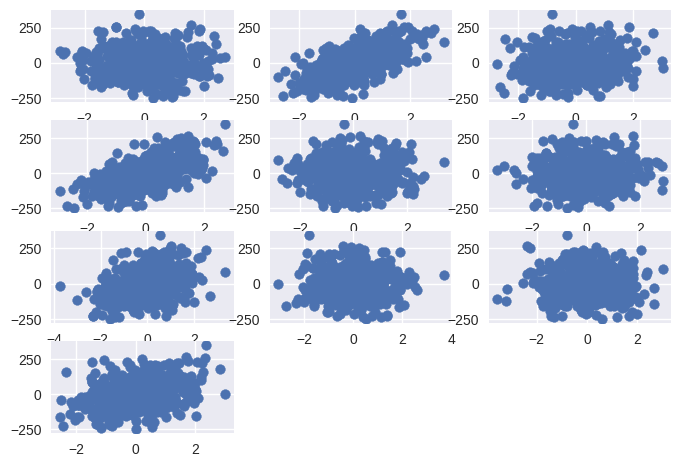

In [43]:
# Step-3 Visualise y as a function of each feature

for f in range(0,10):
  plt.subplot(4,3,f+1)
  plt.scatter(X[:,f],y)
plt.show()

In [44]:
# Step-4 Train Test Split
XT,Xt, yT,yt = train_test_split(X,y,test_size=0.3,shuffle=False,random_state=0)

In [45]:
print(XT.shape,yT.shape)
print(Xt.shape,yt.shape)

(350, 10) (350,)
(150, 10) (150,)


In [46]:
# Step -5 Modelling/ Linear Regression with Multiple Features
def preprocess(X):
  # add a column of 1s in X as 0th column
  if X.shape[1] == n_features:
    m = X.shape[0]
    ones = np.ones((m,1))
    X = np.hstack((ones,X))

  return X

In [47]:
def hypothesis(X,theta):
  return np.dot(X,theta)

def loss(X,y,theta):
  yp = hypothesis(X,theta)
  error = np.mean((y-yp)**2)

  return error

def gradient(X,y,theta):
  yp = hypothesis(X,theta)
  grad = np.dot(X.T,(yp-y))
  m = X.shape[0]

  return grad/m

def train(X,y,learning_rate = 1, max_iters=100):
  n = X.shape[1]
  theta = np.random.randn(n)
  error_list = []

  for i in range(max_iters):
    e = loss(X,y,theta)
    error_list.append(e)
    grad = gradient(X,y,theta)
    theta = theta - learning_rate * grad

  plt.plot(error_list)
  return theta



[-1.65260283e-01  6.05023623e+01  1.04274693e+01  6.36056679e+01
 -4.42322580e-02 -2.18959400e-01  4.08375335e+01 -7.01838035e-02
 -5.56558960e-02  2.54761637e+01]


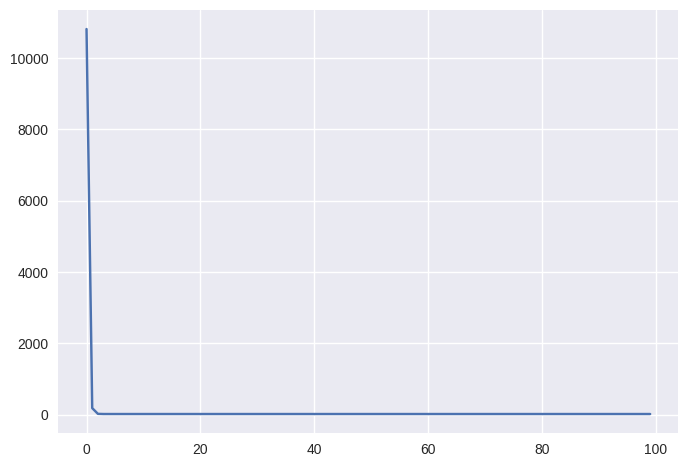

In [48]:
theta = train(XT,yT)
print(theta)

In [49]:
print(theta.shape)

(10,)


In [50]:
gradient(XT,yT,theta).shape

(10,)

In [51]:
# Model Evaluation using R2Score
def r2Score(y,yp):
  ymean = y.mean()
  num = np.sum((y-yp)**2)
  denom = np.sum((y-ymean)**2)

  return (1 - num/denom)*100

In [52]:
yp = hypothesis(Xt, theta)

In [53]:
r2Score(yt,yp)

np.float64(99.82481400351197)

In [54]:
## Linear Regression with Sk-Learn

In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()

In [57]:
model.fit(XT,yT)

LinearRegression()

In [58]:
yp = model.predict(Xt)

In [59]:
yp.shape

(150,)

In [60]:
model.score(Xt,yt)

0.9995692220028003

In [61]:
model.intercept_

np.float64(-3.830965832241088)

In [63]:
model.coef_.shape

(10,)

In [64]:
model.coef_

array([-2.06171871e-02,  6.04374523e+01,  1.06974366e+01,  6.35793325e+01,
       -3.74345796e-02,  7.24956651e-02,  4.09293832e+01,  4.23429505e-02,
        5.84283306e-02,  2.53368186e+01])